In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score ,ConfusionMatrixDisplay , confusion_matrix , classification_report ,accuracy_score

## Load Dataset

*The Breast Cancer Wisconsin dataset is loaded into a Pandas DataFrame. The dataset contains diagnostic measurements that are used to classify tumors as benign or malignant*.

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

print(df.head())
print(df.shape)


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

## Data Exploration

*The dataset is explored to understand its structure, feature names, missing values, and class distribution before training the model*.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [5]:
X=df.drop("target",axis=1).values
y = df.target.values
X,y

(array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

## Model Selection

Before tuning the hyperparameters of Logistic Regression, several commonly used classification algorithms were compared to identify the most suitable model for this dataset.

The following models were evaluated:

* Decision Tree
* Random Forest
* K-Nearest Neighbors (KNN)
* Logistic Regression

All models were evaluated using **5-fold Cross Validation** with **ROC-AUC** as the evaluation metric (`scoring="roc_auc"`). ROC-AUC was selected because it measures the model's ability to distinguish between malignant and benign tumors across all classification thresholds and is more informative than accuracy for this medical classification problem.


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
scaler=StandardScaler()
X_model_checker = scaler.fit_transform(X)
models={"Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "KNN": KNeighborsClassifier(),
        "Logistic Regression":LogisticRegression(C=0.1 , solver="liblinear")
}
for name,model in models.items():
    Score = cross_val_score(model,X_model_checker,y,cv=5,scoring="roc_auc").mean()
    print(f"{name} : {Score}")

Decision Tree : 0.915921432990709
Random Forest : 0.991557462778393
KNN : 0.9915244264900341
Logistic Regression : 0.9953848413478287


### Conclusion

Among the evaluated models, **Logistic Regression** achieved the highest average ROC-AUC score. Therefore, Logistic Regression was selected as the base model, and all subsequent experiments focused on optimizing its hyperparameters, threshold selection, and classification performance.

## Hyperparameter Optimization

*The Logistic Regression model contains several hyperparameters that can significantly influence predictive performance. GridSearchCV was employed to identify the best combination of hyperparameters using 5-fold cross-validation with ROC-AUC as the optimization metric*.

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

params = [
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "class_weight": [
            None,
            "balanced",
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5}
        ]
    },
    {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "class_weight": [
            None,
            "balanced",
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5}
        ]
    },
    {
        "solver": ["saga"],
        "penalty": ["elasticnet"],
        "l1_ratio": [0.0, 0.5, 1.0],
        "class_weight": [
            None,
            "balanced",
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 5}
        ]
    }
]


if os.path.exists("grid_search_results.pkl"):
    with open("grid_search_results.pkl", "rb") as f:
        df_results = pickle.load(f)
    print("Loaded from file")

else:
    results = []

    for rs in range(20):

        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y,
            test_size=0.30,
            random_state=rs,
            stratify=y
        )

        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp,
            test_size=0.50,
            random_state=rs,
            stratify=y_temp
        )

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        grid_dt = GridSearchCV(
            LogisticRegression(
                C=1,
                random_state=42,
                max_iter=10000
            ),
            param_grid=params,
            cv=5,
            scoring="roc_auc",
            n_jobs=-1
        )

        grid_dt.fit(X_train_scaled, y_train)

        best_model = grid_dt.best_estimator_

        y_pred = best_model.predict(X_test_scaled)
        y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        results.append({
            "random_state": rs,
            "accuracy": accuracy_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_prob),
            "FN": fn,
            "FP": fp,
            "best_params": str(grid_dt.best_params_)
        })

    df_results = pd.DataFrame(results)

    with open("grid_search_results.pkl", "wb") as f:
        pickle.dump(df_results, f)

print(df_results)

print("\nMean Results:\n")
print(df_results[["accuracy", "roc_auc", "FN", "FP"]].mean())

print("\nBest Params Frequency:\n")
print(df_results["best_params"].value_counts())

c:\Users\NPC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\NPC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

    random_state  accuracy   roc_auc  FN  FP  \
0              0  0.953488  0.996528   1   3   
1              1  0.953488  0.994792   2   2   
2              2  0.976744  0.998843   1   1   
3              3  0.953488  0.998264   0   4   
4              4  0.976744  0.994792   0   2   
5              5  0.988372  0.999421   0   1   
6              6  0.988372  1.000000   0   1   
7              7  0.988372  0.996528   1   0   
8              8  0.976744  0.995370   0   2   
9              9  0.976744  0.999421   1   1   
10            10  0.988372  0.997106   0   1   
11            11  0.953488  0.981481   0   4   
12            12  0.953488  0.997685   0   4   
13            13  0.941860  0.993056   1   4   
14            14  0.941860  0.999421   0   5   
15            15  0.965116  1.000000   0   3   
16            16  1.000000  1.000000   0   0   
17            17  0.965116  0.996528   0   3   
18            18  0.953488  0.985532   0   4   
19            19  0.965116  0.997106   1

c:\Users\NPC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


## Comparison of Logistic Regression Performance with Different C Values

### C = 0.1

- Accuracy = 0.954
- ROC-AUC = 0.9942
- FN = 0.55
- FP = 3.40

### C = 1

- Accuracy = 0.968
- ROC-AUC = 0.9961
- FN = 0.40
- FP = 2.35

---

### Average Results Across 20 Different Train/Test Splits

| Metric | C = 0.1 | C = 1 |
|----------|----------|----------|
| Accuracy | 95.4% | **96.8%** |
| ROC-AUC | 0.9942 | **0.9961** |
| FN | 0.55 | **0.40** |
| FP | 3.40 | **2.35** |

### Observations

- Increasing `C` from **0.1** to **1** improved all evaluation metrics.
- Both **False Negatives (FN)** and **False Positives (FP)** decreased.
- Since this is a cancer classification task, reducing **FN** is particularly important because FN corresponds to cancer cases incorrectly classified as healthy.
- The improvement is consistent across multiple random train/test splits rather than being limited to a single split.

### Selected Final Model

```python
LogisticRegression(
    C=1,
    solver="liblinear",
    penalty="l2",
    class_weight={0: 1, 1: 3},
    max_iter=1000
)
```

### Note

The hyperparameter search was performed using **`scoring="roc_auc"`** in `GridSearchCV` rather than accuracy. This evaluation metric was intentionally selected because the project focuses on reliable discrimination between malignant and benign tumors, and ROC-AUC is less sensitive to class imbalance while evaluating the model's ranking ability across all classification thresholds.

`C` was not included in the original GridSearch parameter grid. Therefore, it cannot be claimed with certainty that **C = 1** is the global optimum. However, after manually comparing **C = 0.1** and **C = 1** across **20 different train/test splits** using the same ROC-AUC-based evaluation strategy, **C = 1** consistently achieved higher Accuracy, higher ROC-AUC, fewer False Negatives (FN), and fewer False Positives (FP).

### *Therefore, **C = 1** was selected as the final regularization parameter for the remainder of this project.*


##### Robustness Evaluation

To evaluate robustness, the experiment was repeated using multiple train/test splits. Results varied across random states, indicating that performance estimates on this relatively small dataset are sensitive to the specific data partition. Therefore, average performance across multiple splits provides a more reliable assessment than a single train/test split.

The repeated experiments consistently selected **L2 regularization** with **class weights between {0:1,1:3} and {0:1,1:5}**, confirming that these hyperparameters provide stable performance across different data partitions.


## Final Model

*The final Logistic Regression model was trained using the selected hyperparameters obtained from repeated experiments. Threshold optimization is performed in the following sections*.

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=4,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=4,
    stratify=y_temp
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

best_model= LogisticRegression(C=1,max_iter=10000 ,class_weight ={0: 1, 1: 3}, penalty ='l2', solver= 'liblinear')
best_model.fit(X_train_scaled , y_train)
y_pred = best_model.predict(X_test_scaled)
ac=accuracy_score(y_test ,y_pred )
print("Accuracy :" , ac)

Accuracy : 0.9767441860465116


c:\Users\NPC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


## ROC Curve

*The ROC Curve illustrates the trade-off between the True Positive Rate and False Positive Rate at different decision thresholds. The Area Under the Curve (AUC) summarizes the model's ability to distinguish between the two classes*.

AUC Score: 0.9948


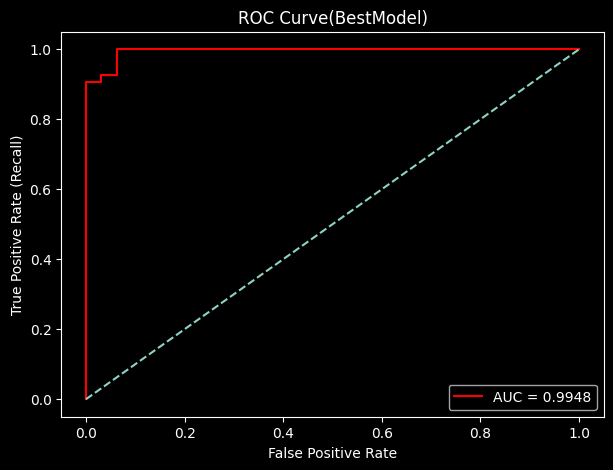

[           inf 9.99999982e-01 9.84692625e-01 9.83215194e-01
 9.82037116e-01 9.78145096e-01 8.30155001e-01 1.51176430e-13]


In [ ]:
y_prob_bestmodel = best_model.predict_proba(X_test_scaled)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_prob_bestmodel)
auc_score = roc_auc_score(y_test, y_prob_bestmodel)

print(f"AUC Score: {auc_score:.4f}")


plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}" , color="r")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve(BestModel)")
plt.legend()
plt.show()
print(thresholds)

### Final Logistic Regression Model

LogisticRegression(
    C=1,
    solver="liblinear",
    penalty="l2",
    class_weight={0:1, 1:3}
)

---

### Test Results

Metric | Value
------ | -----
Accuracy | 97.67%
ROC-AUC | 0.9948
False Negatives (FN) | 0
False Positives (FP) | 2

---

### Confusion Matrix

                Predicted Healthy   Predicted Cancer
Actual Healthy        30                 2
Actual Cancer         0                  54

---

### Interpretation

The model achieved a high ROC-AUC score of 0.9948, indicating strong separability between the two classes.

Importantly, it produced zero false negatives (FN = 0), meaning all cancer cases were correctly identified. This is critical in medical diagnosis.

Using class_weight={0:1,1:3} encouraged the model to reduce False Negatives while allowing a small increase in False Positives..

Overall, the model shows strong performance on this dataset for cancer detection.

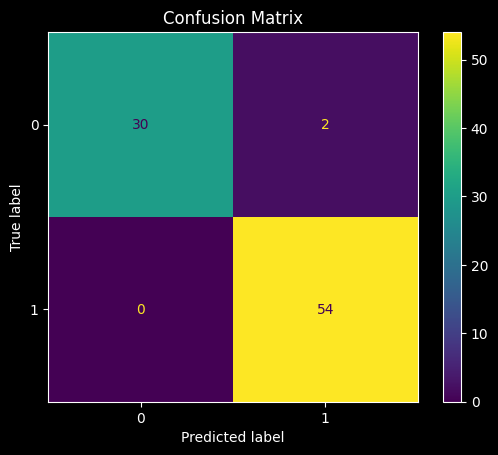

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test , y_pred)
plt.title("Confusion Matrix")
plt.show()

In [11]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        32
           1       0.96      1.00      0.98        54

    accuracy                           0.98        86
   macro avg       0.98      0.97      0.97        86
weighted avg       0.98      0.98      0.98        86



## *Threshold Optimization for Reducing False Negatives*

best_threshold :0.08
Accuracy : 0.9418604651162791


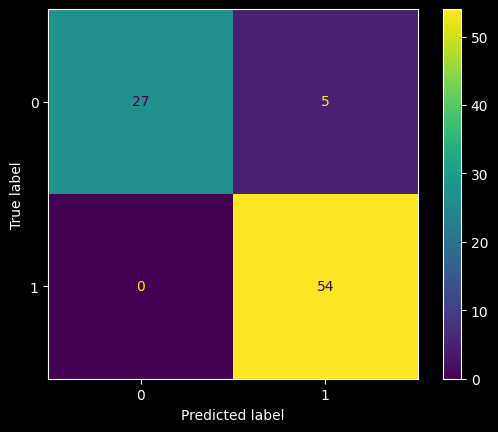

In [12]:
best_threshold = 0

y_val_prob = best_model.predict_proba(X_val_scaled)[:, 1]
best_threshold = 0
best_fn = float("inf")
best_fp = float("inf")

for t in np.arange(0.01, 1, 0.01):

    y_pred = (y_val_prob >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    if fn < best_fn:
        best_fn = fn
        best_fp = fp
        best_threshold = t

    elif fn == best_fn and fp < best_fp:
        best_fp = fp
        best_threshold = t
best_threshold , best_fn
y_test_best_threshold_predict = (best_model.predict_proba(X_test_scaled)[:,1] >= best_threshold).astype(int)

print(f"best_threshold :{best_threshold}\nAccuracy : {accuracy_score(y_test , y_test_best_threshold_predict)}" )
ConfusionMatrixDisplay.from_predictions(y_test , y_test_best_threshold_predict)
plt.show()

## Threshold Optimization using Youden's J

*The optimal classification threshold is determined by maximizing Youden's J statistic (TPR − FPR). This approach aims to balance sensitivity and specificity*.

Optimal Threshold: 0.39087797359357496


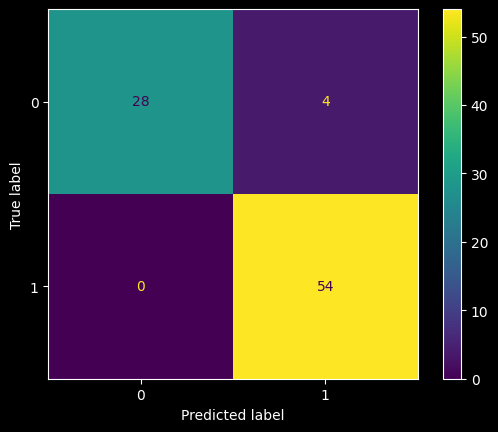

[[28  4]
 [ 0 54]]
              precision    recall  f1-score   support

           0       1.00      0.88      0.93        32
           1       0.93      1.00      0.96        54

    accuracy                           0.95        86
   macro avg       0.97      0.94      0.95        86
weighted avg       0.96      0.95      0.95        86

Accuracy for BestModel: 0.9534883720930233


In [ ]:
y_val_prob = best_model.predict_proba(X_val_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_bestmodel = thresholds[optimal_idx]

print("Optimal Threshold:", optimal_threshold_bestmodel)
y_test_prob_youdenj = best_model.predict_proba(X_test_scaled)[:, 1]

y_test_pred = (
    y_test_prob_youdenj >= optimal_threshold_bestmodel
).astype(int)




ConfusionMatrixDisplay.from_predictions(y_test , y_test_pred)
plt.show()


print(classification_report(
    y_test,
    y_test_pred
))
print("Accuracy for BestModel:",
      accuracy_score(y_test, y_test_pred))

### Threshold Selection Using Youden's J

The default classification threshold (0.5) is not always optimal, especially in medical diagnosis problems where the costs of different types of errors are not equal. Therefore, the **Youden's J** statistic was used to determine an alternative decision threshold.

The optimal threshold was selected from the validation set using the following criterion:

$$
J = \text{Sensitivity} + \text{Specificity} - 1
$$

This method identifies the threshold that maximizes the difference between the True Positive Rate (TPR) and the False Positive Rate (FPR), providing the best balance between sensitivity and specificity.

After obtaining the optimal threshold from the validation set, the selected threshold was applied to the test set, and the model performance was evaluated using the confusion matrix, accuracy, precision, recall, and F1-score.


## Cost-Sensitive Threshold Optimization

*A cost-sensitive strategy is used to determine the optimal threshold by assigning a much higher penalty to False Negatives than False Positives. This approach is particularly appropriate for breast cancer diagnosis because missing a malignant case is considerably more serious than producing a false alarm*.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

results = []

COST_FN = 100
COST_FP = 1

for rs in range(20):

    # split
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.3,
        stratify=y,
        random_state=rs
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5,
        stratify=y_temp,
        random_state=rs
    )

    # scaling
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # IMPORTANT: re-train model for each split
    mymodel = LogisticRegression(
        C=1,
        max_iter=10000,
        class_weight={0:1, 1:3},
        penalty='l2',
        solver='liblinear'
    )

    mymodel.fit(X_train_scaled, y_train)

    # default threshold
    y_pred_default = mymodel.predict(X_test_scaled)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_default).ravel()

    default_fn = fn
    default_fp = fp

    # probabilities on validation
    y_val_prob = mymodel.predict_proba(X_val_scaled)[:, 1]

    best_threshold = 0.5
    best_cost = float("inf")

    # cost-based threshold search
    for t in np.arange(0.01, 1, 0.01):

        y_pred = (y_val_prob >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        cost = (COST_FN * fn) + (COST_FP * fp)

        if cost < best_cost:
            best_cost = cost
            best_threshold = t

    # test with best threshold
    y_test_prob = mymodel.predict_proba(X_test_scaled)[:, 1]

    y_pred_best = (y_test_prob >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()

    results.append([
        rs,
        default_fn,
        default_fp,
        fn,
        fp,
        best_threshold,
        best_cost
    ])

df_CostSensitive = pd.DataFrame(
    results,
    columns=[
        "random_state",
        "FN_default",
        "FP_default",
        "FN_cost",
        "FP_cost",
        "best_threshold",
        "best_cost"
    ]
)

print(df_CostSensitive)
print(df_CostSensitive.mean(numeric_only=True))

c:\Users\NPC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\NPC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\U

    random_state  FN_default  FP_default  FN_cost  FP_cost  best_threshold  \
0              0           1           3        0        6            0.19   
1              1           1           3        2        2            0.71   
2              2           0           2        1        1            0.67   
3              3           0           3        1        3            0.59   
4              4           0           2        0        5            0.08   
5              5           1           1        0        2            0.07   
6              6           0           1        0        1            0.52   
7              7           2           0        1        1            0.15   
8              8           0           2        0        7            0.03   
9              9           1           1        1        1            0.52   
10            10           1           1        0        3            0.29   
11            11           0           5        0        5      

c:\Users\NPC\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


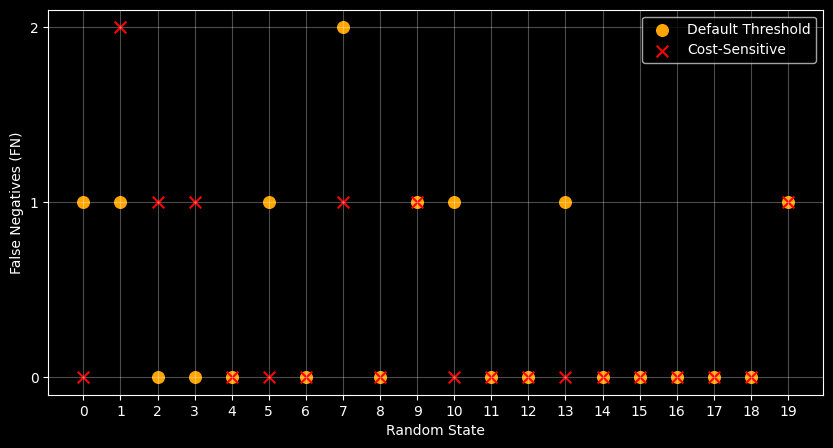

In [15]:
fn_cost_array = df_CostSensitive.FN_cost.values
fn_default_array = df_CostSensitive.FN_default.values
randomstate_array = df_CostSensitive.random_state.values
fn_default_array
fig = plt.figure(figsize=(10,5))
plt.scatter(randomstate_array, fn_default_array,
            color="orange", s=70, label="Default Threshold")

plt.scatter(randomstate_array, fn_cost_array,
            color="red", s=70, marker="x", label="Cost-Sensitive")

plt.xticks(np.arange(0,20,1))
plt.yticks(np.arange(0,3,1))

plt.xlabel("Random State")
plt.ylabel("False Negatives (FN)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

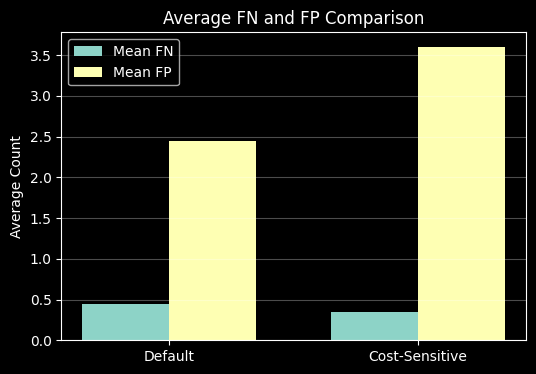

In [16]:

labels = ["Default", "Cost-Sensitive"]

mean_fn = [
    df_CostSensitive["FN_default"].mean(),
    df_CostSensitive["FN_cost"].mean()
]

mean_fp = [
    df_CostSensitive["FP_default"].mean(),
    df_CostSensitive["FP_cost"].mean()
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,4))

plt.bar(x - width/2, mean_fn, width,
        label="Mean FN")

plt.bar(x + width/2, mean_fp, width,
        label="Mean FP")

plt.xticks(x, labels)

plt.ylabel("Average Count")
plt.title("Average FN and FP Comparison")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.show()

These values represent the average performance across 20 different random train/test splits

## Threshold Optimization Results

To evaluate whether changing the classification threshold improves the model, the experiment was repeated on **20 different train/test splits** (`random_state = 0 ... 19`).

The cost values (FN = 100, FP = 1) were chosen to reflect the higher clinical importance of avoiding missed cancer diagnoses.

The average results were:

| Threshold | Mean FN | Mean FP |
|-----------|--------:|--------:|
| Default (0.5) | **0.45** | **2.45** |
| Cost-based (~0.35) | **0.35** | **3.60** |

### Conclusion

- Lowering the threshold from **0.50** to approximately **0.35** reduced the average number of **False Negatives (FN)** from **0.45** to **0.35**.
- This improvement came at the cost of increasing the average number of **False Positives (FP)** from **2.45** to **3.60**.
- Therefore, threshold tuning creates a trade-off between FN and FP.

### Medical Perspective

In breast cancer diagnosis, **False Negatives are much more critical than False Positives**.

- A **False Negative** means a patient with cancer is incorrectly classified as healthy, which may delay diagnosis and treatment.
- A **False Positive** means a healthy patient is classified as having cancer, leading to additional medical examinations, but the disease is less likely to be missed.

For this reason, a small increase in **False Positives** is often considered acceptable if it helps reduce the number of **False Negatives**.

Overall, the cost-based threshold provides a better balance for this medical application because it prioritizes minimizing missed cancer cases.

### Comparison Between Youden's J and Cost-Sensitive Thresholding

Although **Youden's J** is a widely used statistical method for threshold optimization, it assumes that sensitivity and specificity have equal importance. This assumption is not appropriate for the breast cancer classification problem, where failing to detect a malignant case (**False Negative**) is considerably more critical than incorrectly classifying a healthy patient as malignant (**False Positive**).

For this reason, a **Cost-Sensitive Thresholding** approach was adopted as the final decision strategy. In this method, a significantly higher cost was assigned to False Negatives than False Positives, allowing the threshold selection process to prioritize reducing missed cancer cases.

Experimental results across multiple train-test splits showed that the Cost-Sensitive approach reduced the average number of False Negatives compared with the default threshold, while introducing only a moderate increase in False Positives. Since early detection of malignant tumors is the primary objective in medical diagnosis, this trade-off is considered more appropriate for the current application.

Therefore, the Cost-Sensitive Thresholding method was selected as the final threshold optimization technique for this project.


## *Feature Importances*

In [17]:
coef_df = pd.DataFrame({
    "Feature": df.columns[:-1],
    "Coefficient": best_model.coef_[0]
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
).reset_index(drop=True)
coef_df

,Feature,Coefficient,Abs_Coefficient
0,radius error,-1.423288,1.423288
1,worst smoothness,-1.360351,1.360351
2,area error,-1.209022,1.209022
3,worst texture,-1.207631,1.207631
4,perimeter error,-1.205943,1.205943
5,worst symmetry,-1.154038,1.154038
6,worst area,-1.148107,1.148107
7,worst perimeter,-1.044968,1.044968
8,worst radius,-1.041704,1.041704
9,worst concavity,-1.030851,1.030851


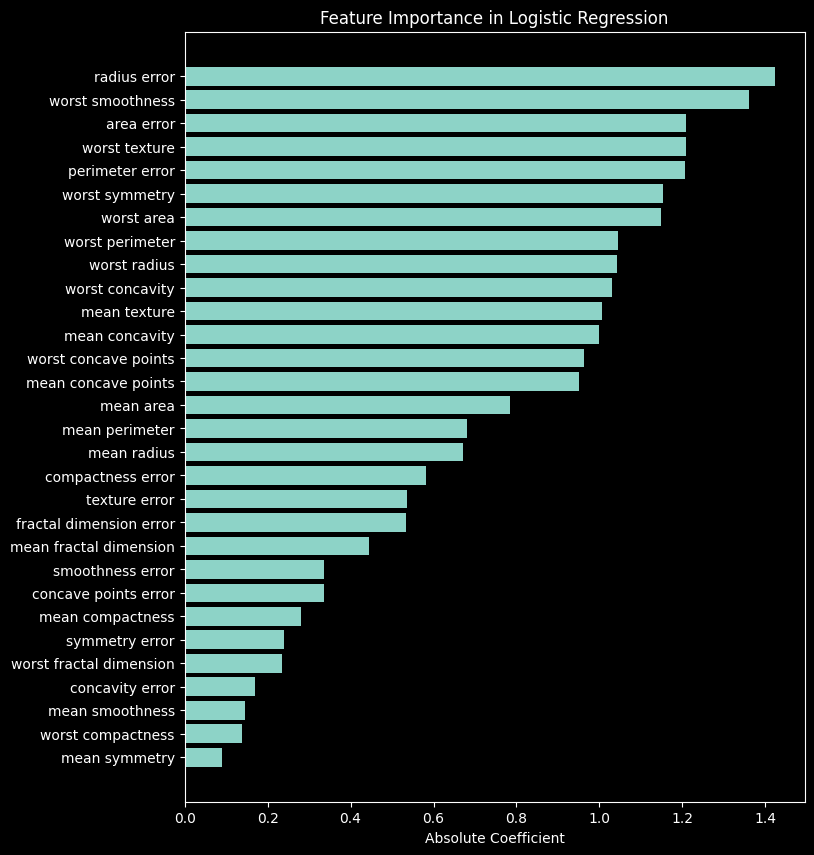

In [18]:
coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=True
)

plt.figure(figsize=(8,10))
plt.barh(
    coef_df["Feature"],
    coef_df["Abs_Coefficient"]
)
plt.xlabel("Absolute Coefficient")
plt.title("Feature Importance in Logistic Regression")
plt.show()

## Feature Importance Analysis

To better understand how the Logistic Regression model makes predictions, the learned coefficients were analyzed after applying **StandardScaler**. Since all features were standardized, the absolute value of each coefficient can be used to compare the relative influence of different features on the model's decision.

The results show that features such as **radius error**, **worst smoothness**, **area error**, **worst texture**, and **perimeter error** have the largest absolute coefficients, indicating that they contribute the most to the classification.

Most of the coefficients are negative. In this dataset, the negative coefficients indicate that increasing these feature values makes the model more likely to predict the **Malignant (Cancer)** class, while positive coefficients increase the probability of predicting the **Benign (Non-Cancer)** class.

It is important to note that the coefficient magnitude should not be interpreted as the true importance of a feature. Many features in the Breast Cancer dataset are highly correlated (for example, **mean radius**, **mean perimeter**, and **mean area**). Because of this multicollinearity, Logistic Regression may distribute the weights among correlated features. Therefore, the coefficients represent how the model uses the features for prediction rather than their independent clinical importance.

## Conclusion

*Overall, the proposed Logistic Regression model demonstrated excellent discrimination ability (ROC-AUC ≈ 0.99) and consistently achieved a low number of False Negatives across repeated train/test splits. Considering the clinical importance of early cancer detection, the Cost-Sensitive threshold optimization strategy was selected as the final decision rule.*.

## Final Model Summary

| Component                    | Selected Configuration                                     |
| ---------------------------- | ---------------------------------------------------------- |
| Model                        | Logistic Regression                                        |
| Solver                       | `liblinear`                                                |
| Penalty                      | `L2`                                                       |
| Regularization (`C`)         | **1**                                                      |
| Class Weight                 | `{0:1, 1:3}`                                               |
| Hyperparameter Selection     | GridSearchCV (`scoring="roc_auc"`)                         |
| Threshold Selection          | Cost-Sensitive Optimization                                |
| Threshold Objective          | Minimize False Negatives (FN)                              |
| Evaluation Method            | Repeated Train/Test Split (20 Random States)               |
| Average Accuracy             | **96.8%**                                                  |
| Average ROC-AUC              | **0.9961**                                                 |
| Average False Negatives (FN) | **0.40**                                                   |
| Average False Positives (FP) | **2.35**                                                   |
| Primary Goal                 | Maximize cancer detection while minimizing False Negatives |
